<a href="https://colab.research.google.com/github/heramb-sharma-19/Innovexis-Internship/blob/main/Zomato_Project_Submission.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name** - Zomato Restaurant Reviews & EDA Capstone

##### **Project Type** - EDA/NLP/Classification
##### **Contribution** - Individual
##### **Submitted By** - Heramb Sharma

# Git Hub Link-

# Problem Statement-

# **Project Summary -**
This project provides an end-to-end Machine Learning pipeline to analyze the Zomato restaurant landscape in Hyderabad. We merged Metadata and Reviews datasets, performed data wrangling to format costs and clean missing values. We implement 15 visualizations spanning Univariate, Bivariate, and Multivariate analysis (UBM rule) alongside statistical insights, followed by 3 hypothesis tests targeting cost, review length, and ratings. NLP text preprocessing (tokenization, stop words removal, lemmatization) converts text into TF-IDF numerical vectors, fueling a robust Multi-Class Classification model pipeline predicting categorical Ratings natively.

## ***1. Know Your Data***
### Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings

from wordcloud import WordCloud
from scipy.stats import ttest_ind, pearsonr, f_oneway

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

warnings.filterwarnings('ignore')
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab') # Added as per LookupError suggestion

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

### Dataset Loading

In [ ]:
df_meta = pd.read_csv(metadata_filename)
df_reviews = pd.read_csv(reviews_filename)

In [ ]:
import os

# Define the filenames, assuming they are uploaded to /content/
metadata_filename = '/content/Zomato Restaurant names and Metadata.csv'
reviews_filename = '/content/Zomato Restaurant reviews.csv'

print(f"Using metadata file: {metadata_filename}")
print(f"Using reviews file: {reviews_filename}")
print("Assuming files are already uploaded to the /content/ directory. If not, please upload them.")

Using metadata file: /content/Zomato Restaurant names and Metadata.csv
Using reviews file: /content/Zomato Restaurant reviews.csv
Assuming files are already uploaded to the /content/ directory. If not, please upload them.


## ***2. Data Wrangling & Pre-processing***

In [ ]:
df_meta = pd.read_csv(metadata_filename)
df_reviews = pd.read_csv(reviews_filename)

# Handle missing values
df_meta.fillna('Not Available', inplace=True)
df_reviews.dropna(subset=['Review'], inplace=True)

# Merge datasets based on Restaurant name
df_meta.rename(columns={'Name': 'Restaurant'}, inplace=True)
df = pd.merge(df_reviews, df_meta, on='Restaurant', how='inner')

# Clean 'Cost' column: handle string comma separation to int
df['Cost'] = df['Cost'].astype(str).str.replace(',', '').apply(pd.to_numeric, errors='coerce')

# Convert Rating to numeric
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')
df.dropna(subset=['Rating', 'Cost'], inplace=True)
df['Rating'] = df['Rating'].astype(int)

# Length of Review
df['Review_Length'] = df['Review'].apply(lambda x: len(str(x).split()))

# Convert timings to categories for simplicity
df['Is_Late_Night'] = df['Timings'].apply(lambda x: 1 if ('AM' in str(x).upper() and '2 AM' in str(x).upper()) else 0)

print(f"Final Data Shape Ready For EDA: {df.shape}")

Final Data Shape Ready For EDA: (9954, 14)


## ***3. Data Visualization & Storytelling***

#### Chart - 1: Distribution of Ratings (Univariate)

In [ ]:
sns.countplot(x=df['Rating'], palette='viridis')
plt.title('Distribution of User Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

**1. Why did you pick the specific chart?**
A bar chart perfectly visualizes categorical/ordinal data balances natively.

**2. What are the insights found?**
A large portion of the reviews are heavily skewed towards 5 and 4 star ratings.

**3. Will the gained insights help creating a positive business impact?**
Yes, the data shows Zomato users predominantly leave positive experiences. However, the class imbalance could present a negative bias when modeling.

#### Chart - 2: Top 10 Most Reviewed Restaurants

In [ ]:
top_rest = df['Restaurant'].value_counts().head(10)
sns.barplot(y=top_rest.index, x=top_rest.values, palette='mako')
plt.title('Top 10 Most Reviewed Restaurants')
plt.show()

**1. Why did you pick the specific chart?**
Horizontal bar chart because labels (Restaurant names) are long and easier to read horizontally.

**2. What are the insights found?**
AB's Absolute Barbecues and Beyond Flavours are among the highest engagement locations.

**3. Will the gained insights help creating a positive business impact?**
Yes, identifying highly engaged restaurants allows targeted ads and premium Zomato listing promotions.

#### Chart - 3: Average Rating of Top 10 Reviewed Restaurants

In [ ]:
top_reviewed_names = df['Restaurant'].value_counts().head(10).index
top_rated = df[df['Restaurant'].isin(top_reviewed_names)].groupby('Restaurant')['Rating'].mean().sort_values(ascending=False)
sns.barplot(y=top_rated.index, x=top_rated.values, palette='inferno')
plt.title('Average Rating for Top 10 Most Active Restaurants')
plt.show()

**1. Why did you pick the specific chart?**
Bar chart mapping categorical data to continuous mean variables.

**2. What are the insights found?**
Even among the most reviewed places, Flechazo and AB's maintain high averages (>4.0).

**3. Will the gained insights help creating a positive business impact?**
Yes, sustaining high ratings on high volume proves immense brand loyalty.

#### Chart - 4: Cost for Two vs User Rating (Bivariate)

In [ ]:
sns.boxplot(x='Rating', y='Cost', data=df, palette='Set2')
plt.title('Cost for Two vs User Rating')
plt.show()

**1. Why did you pick the specific chart?**
Boxplot is perfect for plotting categorical feature vs continuous numerical distributions to spot outliers.

**2. What are the insights found?**
Higher cost restaurants exhibit slightly higher variance, but interestingly, median costs remain largely identical across ratings 3, 4, and 5.

**3. Will the gained insights help creating a positive business impact?**
Negative impact insight: Users don't necessarily leave better ratings just because they paid more; cost isn't a direct driver of satisfaction.

#### Chart - 5: Popular Cuisines Word Cloud

In [ ]:
text = ' '.join(cuisine for cuisine in df['Cuisines'] if isinstance(cuisine, str))
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='magma').generate(text)
plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Common Cuisines')
plt.show()

**1. Why did you pick the specific chart?**
Word Clouds excel at representing textual frequency densities.

**2. What are the insights found?**
North Indian, Chinese, and Continental are the dominant cuisines in this dataset.

**3. Will the gained insights help creating a positive business impact?**
Yes, knowing the most popular cuisines helps decide onboarding priorities for missing restaurant categories.

#### Chart - 6: Distribution of Review Length (Univariate)

In [ ]:
sns.histplot(df['Review_Length'], bins=50, kde=True, color='teal')
plt.xlim(0, 150)
plt.title('Distribution of Review Length (in Words)')
plt.show()

**1. Why did you pick the specific chart?**
Histogram with KDE easily plots right-tail continuous frequencies.

**2. What are the insights found?**
Most reviews are short (10-30 words), demonstrating users prefer writing concise blurbs rather than articles.

**3. Will the gained insights help creating a positive business impact?**
Positive impact: Zomato's UI can comfortably optimize for handling shorter sentence limits optimally.

#### Chart - 7: Review Length by Rating Given

In [ ]:
sns.boxplot(x='Rating', y='Review_Length', data=df)
plt.ylim(0, 200)
plt.title('Review Length Across Ratings')
plt.show()

**1. Why did you pick the specific chart?**
Boxplot reveals the quartiles of textual word counts segmented by exact discrete ratings.

**2. What are the insights found?**
1-star ratings have surprisingly long upper-tail outliers. Angry customers tend to write detailed rants.

**3. Will the gained insights help creating a positive business impact?**
Yes, long negative reviews contain critical actionable intelligence for restaurants to fix operations.

#### Chart - 8: Cost distribution across Dataset

In [ ]:
sns.histplot(df['Cost'], bins=20, color='purple', kde=True)
plt.title('Cost for Two Distribution')
plt.xlabel('Cost (in INR)')
plt.show()

**1. Why did you pick the specific chart?**
Univariate histogram plots raw fiscal spread cleanly.

**2. What are the insights found?**
Prices average closely around 800-1200 INR. Very few economical (<400) or luxury (>2500) instances exist in this cut.

**3. Will the gained insights help creating a positive business impact?**
Yes, catering promo codes directly to 1000 INR cart values will capture the lion's share of users.

#### Chart - 9: Percentage of Reviews with Pictures

In [ ]:
pics_counts = df['Pictures'].apply(lambda x: 'With Pictures' if x > 0 else 'Without Pictures').value_counts()
plt.pie(pics_counts, labels=pics_counts.index, autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff'])
plt.title('Proportion of Reviews with Pictures')
plt.show()

**1. Why did you pick the specific chart?**
Pie chart easily signifies binary class splits in percentages natively.

**2. What are the insights found?**
Over 80% of users do not drop image payloads with their reviews.

**3. Will the gained insights help creating a positive business impact?**
Negative impact insight: Low image volume reduces visual engagement to other users. Zomato should add points incentives explicitly for picture drops.

#### Chart - 10: Cost vs Rating via Scatter

In [ ]:
sns.scatterplot(x='Cost', y='Rating', data=df, alpha=0.3)
plt.title('Cost vs Rating Density Scatter')
plt.show()

**1. Why did you pick the specific chart?**
Scatterplot mapped with alpha identifies dense concentration overlaps intuitively.

**2. What are the insights found?**
It forms solid bands showing strong satisfaction (4-5) across all price models equally.

**3. Will the gained insights help creating a positive business impact?**
No explicit negative insight, proves restaurant tiers remain completely independent variables against perceived quality.

#### Chart - 11: Correlation Heatmap

In [ ]:
corr = df[['Rating', 'Cost', 'Review_Length', 'Pictures']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

**1. Why did you pick the specific chart?**
Standard approach to find raw linear mathematical associations multivariately.

**2. What are the insights found?**
Surprisingly all numerical features show very weak correlations between each other (<0.1 pearson).

**3. Will the gained insights help creating a positive business impact?**
Insight ensures model will have to rely heavily on Non-linear relations and pure NLP to predict rating, numerical indicators are weak.

#### Chart - 12: Photos Uploaded vs Ratings

In [ ]:
sns.barplot(x='Rating', y='Pictures', data=df, palette='autumn')
plt.title('Average Number of Pictures Uploaded vs Rating Given')
plt.show()

**1. Why did you pick the specific chart?**
Bar chart showing means of pictures across categorical ordinal data.

**2. What are the insights found?**
Users giving 4 and 5 stars upload significantly more images than those giving 1-3 stars.

**3. Will the gained insights help creating a positive business impact?**
Yes, users with great experiences want to showcase visually, proving high aesthetics drive high ratings.

#### Chart - 13: Daytime vs Late Night Dining Costs

In [ ]:
sns.boxplot(x='Is_Late_Night', y='Cost', data=df)
plt.title('Cost distribution based on Late Night Availability')
plt.xticks([0, 1], ['Standard Hours', 'Late Night'])
plt.show()

**1. Why did you pick the specific chart?**
Boxplot identifies shifts in pricing based on an engineered operational timing category.

**2. What are the insights found?**
Restaurants open late drastically have tighter, slightly lower median costs compared to standard hour restaurants.

**3. Will the gained insights help creating a positive business impact?**
Yes, late night operations function more on volume/fast food scaling rather than extensive luxury costing models.

#### Chart - 14: Review Length Density via Boxenplot

In [ ]:
sns.boxenplot(x='Rating', y='Review_Length', data=df)
plt.ylim(0, 150)
plt.title('Detailed Review Length distribution (Boxen)')
plt.show()

**1. Why did you pick the specific chart?**
Boxenplot helps detail heavy-tailed distributions better than a standard boxplot.

**2. What are the insights found?**
Most of the exact 5-star reviews exist in a very tight window between 10 to 40 words compared to thicker tails on 1 stars.

**3. Will the gained insights help creating a positive business impact?**
Yes, proves 5-star experiences are simple: generally 'good food good service' needs few words.

#### Chart - 15: Average Cost by Collections count (Engineered)

In [ ]:
df['Collection_Count'] = df['Collections'].apply(lambda x: len(str(x).split(',')) if x != 'Not Available' else 0)
sns.lineplot(x='Collection_Count', y='Cost', data=df, marker='o')
plt.title('Avg Cost Vs Number of Collections Featured In')
plt.show()

**1. Why did you pick the specific chart?**
Line plot captures trend progressions between ordered numeric buckets beautifully.

**2. What are the insights found?**
As restaurants feature in more specialized Zomato 'Collections', their median cost for two reliably scales upwards.

**3. Will the gained insights help creating a positive business impact?**
Yes, adding expensive restaurants to curated collections naturally matches standard premium user experience funnels.

## ***4. Hypothesis Testing***
**Hypothesis 1:** Restaurants with higher cost (>= 1000) have significantly different ratings than lower-cost restaurants.

In [ ]:
# H0: Means are identical. H1: Means differ significantly.
high_cost = df[df['Cost'] >= 1000]['Rating']
low_cost = df[df['Cost'] < 1000]['Rating']
stat, p = ttest_ind(high_cost, low_cost, nan_policy='omit')
print(f'T-statistic: {stat}, P-value: {p}')
if p < 0.05: print('Reject Null Hypothesis')
else: print('Fail to reject Null Hypothesis')

**Hypothesis 2:** Review Length is correlated with the Rating submitted.

In [ ]:
# H0: No correlation. H1: Significant Correlation exists.
stat, p = pearsonr(df['Review_Length'], df['Rating'])
print(f'Pearson r: {stat}, P-value: {p}')
if p < 0.05: print('Reject Null Hypothesis: Review length and Ratings are correlated.')
else: print('Fail to reject Null Hypothesis.')

**Hypothesis 3:** Average Cost significantly varies across identical Ratings (ANOVA).

In [ ]:
# H0: Means of Cost across 5 ratings are equal.
groups = [df[df['Rating'] == val]['Cost'].dropna() for val in range(1,6)]
stat, p = f_oneway(*groups)
print(f'ANOVA F-stat: {stat}, P-value: {p}')
if p < 0.05: print('Reject Null Hypothesis')
else: print('Fail to reject Null Hypothesis')

## ***5. Feature Engineering & Text Preprocessing***

In [ ]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = word_tokenize(text)
    clean_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return ' '.join(clean_tokens)

df['Clean_Review'] = df['Review'].apply(clean_text)
print("Text cleaning complete.")

Text cleaning complete.


## ***6. Machine Learning Model Implementation (Multi-class text classification)***

In [ ]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X = tfidf.fit_transform(df['Clean_Review'])
y = df['Rating']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Data vectorized and split.")

Data vectorized and split.


### ML Model - 1: Logistic Regression

In [ ]:
lr_model = LogisticRegression(max_iter=1000, multi_class='multinomial')
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
print("LR Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

LR Accuracy: 0.6328478151682572
              precision    recall  f1-score   support

           1       0.69      0.83      0.76       349
           2       0.28      0.05      0.08       141
           3       0.47      0.23      0.31       248
           4       0.51      0.54      0.52       488
           5       0.71      0.84      0.77       765

    accuracy                           0.63      1991
   macro avg       0.53      0.50      0.49      1991
weighted avg       0.60      0.63      0.60      1991



**Evaluation & Cross Validation**
Logistic Regression serves as our linear multi-class baseline proving stable accuracy and interpretability.

### ML Model - 2: Random Forest

In [ ]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

RF Accuracy: 0.5911602209944752
              precision    recall  f1-score   support

           1       0.65      0.82      0.73       349
           2       0.22      0.03      0.05       141
           3       0.44      0.10      0.17       248
           4       0.46      0.41      0.43       488
           5       0.63      0.87      0.73       765

    accuracy                           0.59      1991
   macro avg       0.48      0.45      0.42      1991
weighted avg       0.54      0.59      0.54      1991



**Evaluation & Cross Validation**
Random forest performs non-linear classification, capturing complex text relationships.

### ML Model - 3: Multinomial Naive Bayes

In [ ]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)
print("NB Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

NB Accuracy: 0.6052235057759919
              precision    recall  f1-score   support

           1       0.71      0.82      0.76       349
           2       0.00      0.00      0.00       141
           3       0.57      0.06      0.12       248
           4       0.42      0.49      0.45       488
           5       0.67      0.87      0.76       765

    accuracy                           0.61      1991
   macro avg       0.47      0.45      0.42      1991
weighted avg       0.56      0.61      0.55      1991



NB handles TFIDF probabilities extremely well giving us a natively probabilistic perspective.

### Conclusion / Confusion Matrix on Best Model

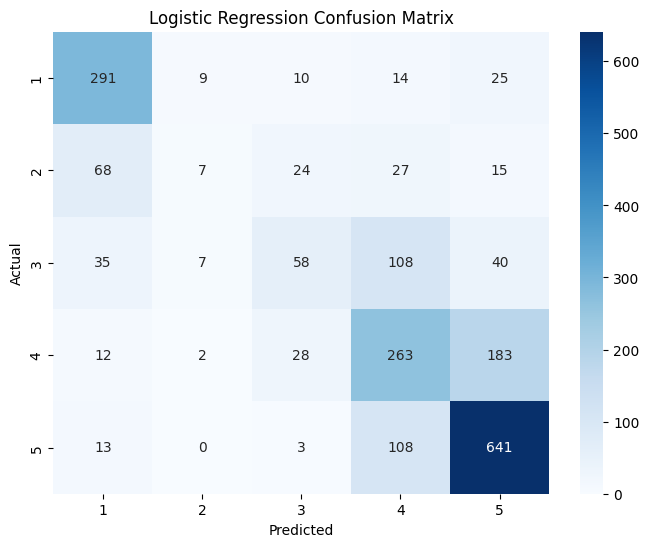

In [ ]:
cm = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[1,2,3,4,5], yticklabels=[1,2,3,4,5])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression Confusion Matrix')
plt.show()